In [3]:
import torch
import torch.multiprocessing as mp
from gymnasium.vector import AsyncVectorEnv
import numpy as np
from env import mbb
from models import ppo
import os
import pandas as pd
import matplotlib.pyplot as plt
import logging
from datetime import datetime
import random
from torch import amp
from env import mbb_cnn
from models import ppo_cnn
from models import surrogate


In [4]:

# Configure logging
logging.basicConfig(
    level=logging.INFO,  # Set to DEBUG for more detailed logs
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler("reward_logs.log"),  # Log to a file
        logging.StreamHandler()  # Also log to console
    ]
)


print("============================================================================================")
device = torch.device('cpu')
if(torch.cuda.is_available()): 
    device = torch.device('cuda:0') 
    torch.cuda.empty_cache()
    print("Device set to : " + str(torch.cuda.get_device_name(device)))
else:
    print("Device set to : cpu")  
print("============================================================================================")


Device set to : NVIDIA GeForce RTX 4070 Laptop GPU


In [5]:
!nvidia-smi

Sun Mar 30 18:56:48 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.120                Driver Version: 550.120        CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4070 ...    Off |   00000000:01:00.0 Off |                  N/A |
| N/A   44C    P8              4W /   80W |     406MiB /   8188MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:


def load_dataset(dataset_path):
    """
    Load dataset from an NPZ file.
    Expected keys: 'states' and 'compliances'
    """
    data = np.load(dataset_path)
    states = data['states']
    compliances = data['compliances']
    return {'states': states, 'compliances': compliances}

def main():
    # Set device and seeds for reproducibility.
    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    torch.manual_seed(0)
    np.random.seed(0)

    # Path to your dataset file generated from PPO training.
    # Update this path if needed.
    dataset_path = os.path.join("dataset", "beam_compliance_dataset_20250330_182755.npz")
    if not os.path.exists(dataset_path):
        raise FileNotFoundError(f"Dataset file not found at {dataset_path}")

    dataset = load_dataset(dataset_path)
    print(f"Loaded dataset with {dataset['states'].shape[0]} examples.")

    # Define grid parameters (match those used during PPO training).
    grid_channels = 5
    grid_height = 7
    grid_width = 7

    # Initialize the surrogate model.
    surrogate_model = surrogate.SurrogateModel(grid_channels, grid_height, grid_width)
    surrogate_model.to(device)

    # Set hyperparameters for training.
    batch_size = 32
    epochs = 200
    learning_rate = 1e-3

    # Train the surrogate model using the provided dataset.
    loss_history, grad_norm_history = surrogate_model.train_model(
        dataset,
        batch_size=batch_size,
        epochs=epochs,
        learning_rate=learning_rate,
        device=device
    )

    # Plot the training metrics.
    surrogate_model.plot_training_metrics(loss_history, grad_norm_history, save_path="training_metrics.png")

    # Save the trained surrogate model.
    model_save_path = os.path.join("surrogate_models", "surrogate_model.pth")
    os.makedirs(os.path.dirname(model_save_path), exist_ok=True)
    torch.save(surrogate_model.state_dict(), model_save_path)
    print(f"Trained surrogate model saved at: {model_save_path}")




Loaded dataset with 1600128 examples.
Starting training of the surrogate model...
Epoch 1/200, Loss: 1.1614, Avg Grad Norm: 23.0769
Epoch 2/200, Loss: 0.3738, Avg Grad Norm: 14.0212
Epoch 3/200, Loss: 0.2659, Avg Grad Norm: 11.2851
Epoch 4/200, Loss: 0.2127, Avg Grad Norm: 9.4728
Epoch 5/200, Loss: 0.1794, Avg Grad Norm: 8.2884
Epoch 6/200, Loss: 0.1566, Avg Grad Norm: 7.2389
Epoch 7/200, Loss: 0.1392, Avg Grad Norm: 6.7057
Epoch 8/200, Loss: 0.1297, Avg Grad Norm: 6.3107
Epoch 9/200, Loss: 0.1194, Avg Grad Norm: 5.8682
Epoch 10/200, Loss: 0.1095, Avg Grad Norm: 5.4824
Epoch 11/200, Loss: 0.1017, Avg Grad Norm: 5.1974
Epoch 12/200, Loss: 0.0972, Avg Grad Norm: 4.9678
Epoch 13/200, Loss: 0.0931, Avg Grad Norm: 4.8576
Epoch 14/200, Loss: 0.0889, Avg Grad Norm: 4.7268
Epoch 15/200, Loss: 0.0861, Avg Grad Norm: 4.6673
Epoch 16/200, Loss: 0.0831, Avg Grad Norm: 4.5979
Epoch 17/200, Loss: 0.0789, Avg Grad Norm: 4.5053
Epoch 18/200, Loss: 0.0777, Avg Grad Norm: 4.5637
Epoch 19/200, Loss: 0.07

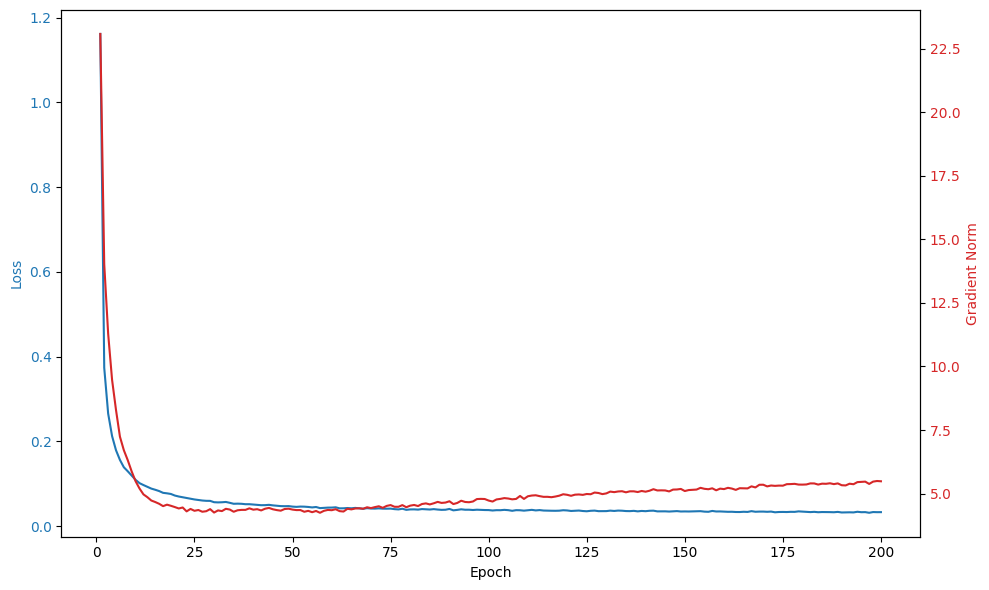

Trained surrogate model saved at: surrogate_models/surrogate_model.pth


In [7]:
if __name__ == "__main__":
    main()

In [13]:
model = surrogate.SurrogateModel(grid_channels=5, grid_height=7, grid_width=7, normalize=True)

# Load the state dictionary into the model.
state_dict = torch.load("surrogate_models/surrogate_model.pth", map_location=torch.device('cpu'))
model.load_state_dict(state_dict)
model.eval()

# Create an input state that matches the expected shape.
# For instance, a state of ones with shape (batch_size, channels, height, width)
state = np.ones((1, 5, 7, 7), dtype=np.float32)  # batch size of 1

# Predict compliance.
predicted_compliance = model.predict(state)
print(predicted_compliance)


[[-66732696.]]


/tmp/ipykernel_5501/88638865.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load("surrogate_models/surrogate_model.pth", map_location=torch.device('c

In [18]:
from utils import fem

# Instantiate and load the surrogate model.
model = surrogate.SurrogateModel(grid_channels=5, grid_height=7, grid_width=7, normalize=True)
state_dict = torch.load("surrogate_models/surrogate_model.pth", map_location=torch.device('cpu'))
model.load_state_dict(state_dict)
model.eval()


normals, forces,_  = fem.mbb_beam_1()  # You may need to adjust this call.

# Assume density is either given or fixed (e.g., 0.4 everywhere).
density = np.full((7, 7), 0.4, dtype=np.float32)

# Extract components. We assume normals and forces are stored with the last dimension being [x, y].
normal_x = normals[..., 0]
normal_y = normals[..., 1]
force_x  = forces[..., 0]
force_y  = forces[..., 1]

# Construct the 5-channel state: shape (5, 7, 7).
state = np.stack([density, normal_x, normal_y, force_x, force_y], axis=0)

# Add a batch dimension to get shape (1, 5, 7, 7).
state = state[np.newaxis, ...]

# Predict compliance.
predicted_compliance = model.predict(state)
print("Predicted compliance:", predicted_compliance)


/tmp/ipykernel_5501/824129533.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load("surrogate_models/surrogate_model.pth", map_location=torch.device('

ValueError: all input arrays must have the same shape